# Introduction to Deep Learning with PyTorch

Welcome to the next step! Now that you have grasped basic tensor operations and Autograd, we can start building actual Neural Networks.

In this notebook, we will cover the foundational building blocks of deep learning in PyTorch:
1. **Activation Functions**: Adding non-linearity to our networks.
2. **Linear Layers**: The core fully-connected layers that learn our weights.
3. **Loss Functions**: How we mathematically measure "wrong" predictions.
4. **Regularization (Dropout)**: Preventing our networks from memorizing data.
5. **Sequential Models**: Connecting all of these layers into a pipeline.

Let's import our required packages and visualize some math!

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# We'll use a fixed seed so your results match the solutions!
torch.manual_seed(42)

## 1. Activation Functions
Activation functions add **non-linearity** to neural networks. If we only used linear transformations (like $W x + b$) stacked on top of each other, the entire network could mathematically be simplified to a single linear layer!

Here are three heavily used activation functions:
*   **Sigmoid**: Squeezes values between 0 and 1. Great for output probabilities. \
    $\sigma(x) = \frac{1}{1 + e^{-x}}$
*   **Tanh**: Squeezes values between -1 and 1. \
    $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
*   **ReLU (Rectified Linear Unit)**: The most popular hidden layer activation. It zeros out negative numbers and passes positive numbers completely unchanged. \
    $\text{ReLU}(x) = \max(0, x)$

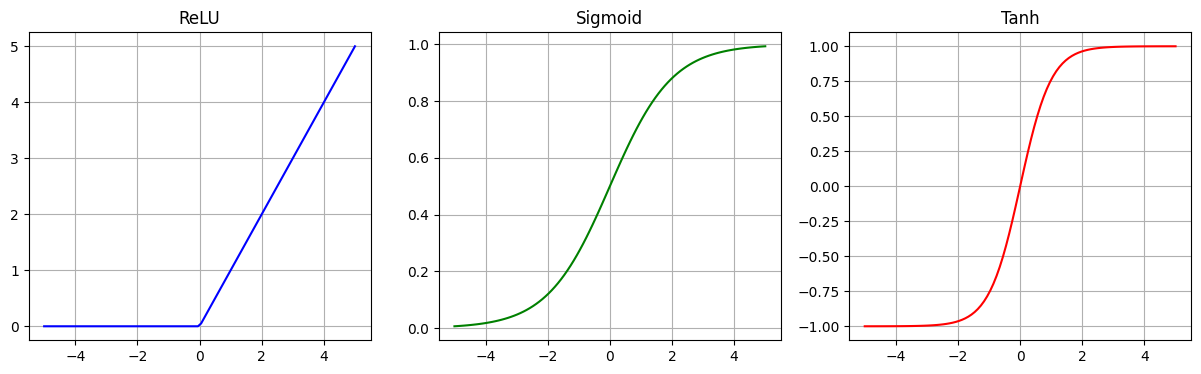

In [ ]:
# Let's plot these standard activation functions!
x = torch.linspace(-5, 5, 100)

# PyTorch provides these natively
relu = torch.relu(x)
sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1); plt.plot(x, relu, color='blue'); plt.title('ReLU'); plt.grid()
plt.subplot(1, 3, 2); plt.plot(x, sigmoid, color='green'); plt.title('Sigmoid'); plt.grid()
plt.subplot(1, 3, 3); plt.plot(x, tanh, color='red'); plt.title('Tanh'); plt.grid()
plt.show()

### Exercise 1: Implementing LeakyReLU
**Task**: Standard ReLU completely zeroing out negative values can lead to a problem called "dead neurons", where neurons stop updating during training. **LeakyReLU** tries to fix this by giving negative values a very small slope.

The mathematical function is:
$\text{LeakyReLU}(x) = \max(0.01x, x)$

Your task is to implement `leaky_manual` using standard tensor masking (like we did in NumPy!). We will then compare it against the native PyTorch implementation `nn.LeakyReLU(0.01)`.

In [ ]:
layer_input = torch.linspace(-5, 5, 20)

# TODO: Implement manual LeakyReLU. Multiply negative values by 0.01.
leaky_manual = ...

# Here is the native PyTorch function calculating it directly:
leaky_pytorch = nn.LeakyReLU(0.01)(layer_input)

# We will check your answer here once you fill it in!
# print("Do they match exactly?", torch.allclose(leaky_manual, leaky_pytorch))

## 2. Linear Layers (`nn.Linear`)
A linear layer (often called a Dense layer or Fully-Connected layer) is the heart of simple neural networks.

Given an input $x$, it computes:
$y = xW^T + b$

Where $W$ is the `.weight` matrix and $b$ is the `.bias` vector. Both of these are trainable parameters (`requires_grad=True` dynamically set under the hood).

In [ ]:
# EXAMPLE: Creating a linear layer
# Takes an input vector of size 3, spits out an output vector of size 2
linear_layer = nn.Linear(in_features=3, out_features=2)

print("Weights Shape:", linear_layer.weight.shape) # (2, 3)
print("Bias Shape:", linear_layer.bias.shape)      # (2,)

print("\nActual Weights Matrix:\n", linear_layer.weight)

Weights Shape: torch.Size([2, 3])
Bias Shape: torch.Size([2])

Actual Weights Matrix:
 Parameter containing:
tensor([[ 0.4414,  0.4792, -0.1353],
        [ 0.5304, -0.1265,  0.1165]], requires_grad=True)


### Exercise 2: The Math of `nn.Linear`
**Task**: Deep Learning isn't magic, it's just matrices! Pass `x_in` through the `linear_layer` utilizing a standard function call.

Then, calculate the exact same output manually using the layer's raw `.weight` and `.bias` matrices, utilizing matrix multiplication (`@`).

In [ ]:
x_in = torch.tensor([1.0, 2.0, 3.0])

# TODO: Pass x_in directly through the linear layer
output_layer = ...

# TODO: Calculate manually using x_in, linear_layer.weight, and linear_layer.bias
# Hint: You will need to transpose the weight matrix using .T
output_manual = ...

# print("\nLayer output:", output_layer)
# print("Manual output:", output_manual)

## 3. Loss Functions
To train a network, we need to mathematically dictate how "wrong" its predictions are. The network uses the gradients from this single Loss value to update itself via Backpropagation.

*   **Regression (Predicting Numbers)** -> **Mean Squared Error (MSE)** \
    $\text{MSE} = \frac{1}{n} \sum (\hat{y} - y)^2$

*   **Classification (Predicting Categories)** -> **Cross Entropy Loss** \
    In PyTorch, `nn.CrossEntropyLoss` expects the **raw, un-normalized outputs** of the model (called logits). It applies the Softmax function itself under the hood for computational stability. Do not manually apply `Softmax` before your Loss function!

In [ ]:
# EXAMPLE: Running MSE Loss (Regression)
mse = nn.MSELoss()

predictions = torch.tensor([1.0, 2.5, 3.0])
true_values = torch.tensor([1.0, 2.0, 3.0])

print("MSE Loss:", mse(predictions, true_values).item())

MSE Loss: 0.0833333358168602


### Exercise 3: Cross Entropy Loss
**Task**: You have 2 sample inputs predicting 3 different possible classes (e.g. Dog, Cat, Bird).
Calculate the Cross Entropy Loss for your predictions.

Requirements for `nn.CrossEntropyLoss(predictions, targets)`:
*   `predictions`: Shape `(Batch_Size, Classes)` containing the raw logits.
*   `targets`: Shape `(Batch_Size,)` containing the **index** of the correct class (e.g., `0`, `1`, or `2`).

In [ ]:
ce_loss_fn = nn.CrossEntropyLoss()

# 2 sample predictions, 3 class logits per sample
logits = torch.tensor([[2.0, -1.0, 0.5],   # Sample 1 heavily predicts Class 0
                       [-0.5, 3.0, 1.0]])  # Sample 2 heavily predicts Class 1

# TODO: Create targets vector of correct answers.
# Make it so Sample 1's true class is 0, and Sample 2's true class is 1.
targets_cls = ...

# TODO: Calculate the loss
loss = ...

# print("Cross Entropy Loss:", loss.item())

## 4. Regularization: Dropout and Weight Decay (L1/L2)
Deep neural networks have millions of parameters; they love to simply memorize your entire training dataset rather than actually learning distinct patterns!

**L1 and L2 Regularization (Weight Decay)**
These techniques penalize the network for having large weights by adding a term to the loss function.
*   **L1 Regularization (Lasso)**: Adds the absolute value of weights to the loss, encouraging sparsity (many weights become exactly 0). \
    $L_1 = \text{Loss} + \lambda \sum |w|$
*   **L2 Regularization (Ridge)**: Adds the squared value of weights to the loss, preventing any single weight from becoming too large. In PyTorch, L2 regularization is easily applied by setting the `weight_decay` parameter in your optimizer (e.g., `torch.optim.Adam(..., weight_decay=1e-4)`). \
    $L_2 = \text{Loss} + \lambda \sum w^2$

**Dropout (`nn.Dropout`)**
Dropout helps stop overfitting by randomly zeroing out elements within a layer during each step of training with a probability $p$. This forces the network's layers to distribute the information learning widely, rather than over-relying on a single dominant neuron.

**Mode Matters:** Dropout is *only* meant to be used while the model is Training (`model.train()`). When performing inference testing (`model.eval()`), the model needs all distinct data completely intact, so Dropout automatically disables itself!

In [ ]:
dropout = nn.Dropout(p=0.5)
sample_data = torch.ones(10)

# 1. Training mode behavior
dropout.train()
print("Train mode output:", dropout(sample_data))

# Notice that the remaining non-zeroed numbers are scaled by exactly 2 (which is 1 / (1-0.5))!
# It scales the weights so the sum stays consistent down the layers.

# 2. Eval mode behavior
dropout.eval()
print("\nEval mode output: ", dropout(sample_data))
# Output identically mimics the input. Dropout is deactivated here.

Train mode output: tensor([0., 2., 0., 0., 2., 2., 2., 2., 0., 0.])

Eval mode output:  tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


## 5. Combining it All: `nn.Sequential`
Instead of calling every layer and activation manually, PyTorch allows us to sequence them together inside an `nn.Sequential` block.

We just pass data into the main `Sequential` model, and it gets automatically piped through the layered definitions sequentially!

### Exercise 4: Build a Deep Neural Network from Scratch!
**Task**: Build a Multi-Layer Perceptron (MLP) for an arbitrary classification task using PyTorch.

Your model must have:
*   Incoming data features: 20
*   A hidden `nn.Linear` layer that maps those 20 features cleanly to **64** hidden features.
*   An `nn.ReLU` activation function.
*   An `nn.Dropout` layer that drops **20%** (0.2) of information.
*   A final `nn.Linear` output layer that shrinks the hidden features down to **5** final distinct class outputs.

In [ ]:
# TODO: Initialize and chain your layers properly!
mlp = nn.Sequential(
    # Insert layers here (separated by commas)
)

# Dummy test data (Batch size of 8 sample rows, 20 features)
dummy_input = torch.randn(8, 20)

# TODO: Pass dummy_input through the mlp
# output = ...
# print("Output shape:", output.shape) # If done right, this should be torch.Size([8, 5])

## 6. Convolutional Neural Networks (`nn.Conv2d`)
If we are dealing with images, flattening them and feeding them into linear layers (MLPs) destroys all spatial information. A pixel in the top-left corner has a physical relationship with the pixel next to it!

**Convolutional Layers** solve this by sliding a small "filter" or "kernel" window over the image to detect features like edges, corners, and eventually complex shapes.

`nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)`
- `in_channels`: E.g., 3 for RGB images, 1 for Grayscale.
- `out_channels`: The number of different feature maps/filters we want to extract.
- `kernel_size`: The size of the sliding window (e.g., 3 means a 3x3 window).

In [ ]:
# EXAMPLE: Passing an image batch through a Conv Layer
# Wait, PyTorch expects image tensors to be in the shape: (Batch, Channels, Height, Width)
batch_size = 4
channels = 3   # RGB
height = 32
width = 32
dummy_images = torch.randn(batch_size, channels, height, width)

# Define a convolution layer that takes 3 incoming color channels
# and produces 16 feature maps using a 3x3 sliding kernel.
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)

output_features = conv_layer(dummy_images)

# Notice how the output channels changed to 16, but Height/Width stayed 32x32 because padding=1 preserved spatial size!
print("Incoming Image Shape:", dummy_images.shape)
print("Output Feature Map Shape:", output_features.shape)

### Exercise 5: Shrinking an Image with Convolution
**Task**: In CNN architectures (like ResNet or VGG), we regularly reduce the spatial dimensions of an image. You can do this by using a `stride=2` (which slides the kernel by jumping 2 pixels at a time, halving the image size), or by using Pooling.

Given a batch of Grayscale images (1 color channel) of size 64x64, pass them through a sequence containing:
1. An `nn.Conv2d` layer that doubles the channels to 8, using a `kernel_size=3` and `stride=2` (with `padding=1`).
2. A `nn.ReLU` activation.

Your final output shape should inherently have height 32 and width 32!

In [ ]:
# Given: Batch of 10 Grayscale images (1 channel), 64x64 pixels.
grayscale_batch = torch.randn(10, 1, 64, 64)

# TODO: Define the conv_sequence model using nn.Sequential
conv_sequence = nn.Sequential(
    # Add your Conv2d layer here
    # Add ReLU here
)

# TODO: Pass the batch through your sequence
# final_cnn_output = ...

# print("Final Shape:", final_cnn_output.shape) # Should be torch.Size([10, 8, 32, 32])

## 7. Custom Architectures (`nn.Module`)
`nn.Sequential` is fantastic for straight straight-line feed-forward networks. But what if your network needs to branch out? What if you want to perform custom math during the forward pass, or create "skip connections" (adding raw inputs directly to deep layers like in ResNet)?

For this, we subclass `nn.Module`. This is the fundamental, professional way to write models in PyTorch.

**Rules of `nn.Module`:**
1. You must call `super().__init__()` inside your `__init__` function.
2. You define your individual layers in `__init__`.
3. You define **how data flows** through those layers in the `forward(self, x)` function.

In [ ]:
# EXAMPLE: A custom Module with a skip connection

class SimpleSkipNet(nn.Module):
    def __init__(self):
        super().__init__() # CRITICAL! Don't forget this.

        # Define our layers
        self.hidden = nn.Linear(10, 10)
        self.relu = nn.ReLU()
        self.output = nn.Linear(10, 5)

    def forward(self, x):
        # 1. Pass input through hidden layer and activation
        h = self.relu(self.hidden(x))

        # 2. Skip connection! We add the raw input directly to the hidden features
        # (This avoids vanishing gradients in very deep networks)
        combined = h + x

        # 3. Pass the combined result to the output
        out = self.output(combined)
        return out

# Let's test it!
model = SimpleSkipNet()
dummy_data = torch.randn(2, 10) # 2 samples, 10 features
print("Model Output Shape:", model(dummy_data).shape)

### Exercise 6: Complete the CNN Classifier Module
**Task**: When working with Images, a classic architecture pattern is `Conv Layers -> Flatten -> Linear Layers`.
You cannot easily do this with just `nn.Sequential` because you need to restructure/flatten the 2D image formats into 1D vectors in the middle of your network!

Complete the `forward` function of the `CNNClassifier` below. You need to pass the data through the convolutions, flatten it, and pass it to the fully connected (linear) layers.

In [ ]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        # Visual Feature Extractor
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2) # Shrinks image by half (e.g. 28x28 -> 14x14)
        )

        # Linear Classifier (assuming an incoming image is 28x28 grayscale)
        # After MaxPool2d, the image is 14x14. We have 16 filters.
        # Total flattened nodes: 16 * 14 * 14 = 3136
        self.classifier = nn.Sequential(
            nn.Linear(3136, 128),
            nn.ReLU(),
            nn.Linear(128, 10) # 10 distinct classes
        )

    def forward(self, x):
        # TODO: 1. Pass `x` through self.features
        # ...

        # TODO: 2. Flatten the features.
        # Hint: Use `x = x.view(x.shape[0], -1)` to keep the batch size intact!
        # ...

        # TODO: 3. Pass flattened `x` through self.classifier
        # ...

        return x

# Test the model!
cnn_model = CNNClassifier()
dummy_mnist_images = torch.randn(5, 1, 28, 28) # A batch of 5 fake MNIST digit images

# print("Final Predictions Shape:", cnn_model(dummy_mnist_images).shape)
# Should be (5, 10)

## 8. Datasets and DataLoaders (`torch.utils.data`)
When dealing with large amounts of data, you cannot load everything into a single massive tensor—it would crash your RAM (and GPU)!

PyTorch solves this using two main classes:
1. `Dataset`: Stores your data and labels. Dictates exactly how a *single* piece of data is fetched.
2. `DataLoader`: Wraps an iterable around the `Dataset`, automatically batching, shuffling, and distributing the data loading across multiple CPU workers.

Let's download a classic ML dataset (Iris flowers) as a CSV file to work with. We'll set the path so it downloads smoothly whether you are offline locally or on Google Colab!

In [ ]:
import os
import urllib.request
import pandas as pd
from torch.utils.data import Dataset, DataLoader

# Setup base directory depending on if we are running in Google Colab or Locally
try:
    import google.colab
    BASE_DIR = '/content/data'
    print("Running in Colab: using %s" % BASE_DIR)
except ImportError:
    BASE_DIR = './data'
    print("Running Locally: using %s" % BASE_DIR)

os.makedirs(BASE_DIR, exist_ok=True)
csv_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
csv_path = os.path.join(BASE_DIR, 'iris.csv')

# Only download if we don't already have it!
if not os.path.exists(csv_path):
    print("Downloading Iris dataset...")
    urllib.request.urlretrieve(csv_url, csv_path)
else:
    print("Dataset already exists locally!")

### Implementing a Custom `Dataset`
To write your own dataset, you subclass `torch.utils.data.Dataset` and must override two magic methods:
*   `__len__(self)`: Tells PyTorch exactly how many total samples exist.
*   `__getitem__(self, idx)`: PyTorch gives you an index `idx` (e.g. 42), and you must return the `idx`-th feature and label.

In [ ]:
# EXAMPLE: Building the Custom Iris Dataset
class IrisDataset(Dataset):
    def __init__(self, csv_file):
        # 1. Load the CSV
        self.data = pd.read_csv(csv_file, header=None)

        # 2. Extract Features (columns 0 through 3 are numerical measurements)
        self.features = torch.tensor(self.data.iloc[:, 0:4].values, dtype=torch.float32)

        # 3. Extract Labels (column 4 contains species strings, we map them to ints)
        label_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
        self.labels = torch.tensor(self.data.iloc[:, 4].map(label_map).values, dtype=torch.long)

    def __len__(self):
        # Return total number of samples
        return len(self.data)

    def __getitem__(self, idx):
        # Return a single (feature, label) pair at the specified index
        return self.features[idx], self.labels[idx]

# Let's instantiate it and test it!
iris_dataset = IrisDataset(csv_path)

print("Total samples in dataset:", len(iris_dataset))
first_feature, first_label = iris_dataset[0]
print("First Sample -> Features:", first_feature, "Label:", first_label)

### Exercise 7: Initialize a `DataLoader`
**Task**: Networks don't train on one sample at a time; they train in **batches**!
A `DataLoader` takes your raw `Dataset` and automatically handles batching, shuffling, and multi-processing for you. You use it similarly to a standard python list.

Create a `DataLoader` for our new `iris_dataset`.
*   Set `batch_size=16`
*   Set `shuffle=True` (Always shuffle your dataset during training so the network doesn't memorize the order!)

Then, loop over the dataloader to grab the very first batch.

In [ ]:
# TODO: Initialize your dataloader
iris_loader = ...

# TODO: Grab the first batch of features and labels
# Hint: You can use `iter()` and `next()` just like any standard python iterator
# features_batch, labels_batch = ...

# print("Features Batch Shape:", features_batch.shape) # Should be [16, 4]
# print("Labels Batch Shape:", labels_batch.shape)     # Should be [16]

---
### Congratulations!
You just implemented Activation functions, learned how forward passing through Linear layers functions under-the-hood, set up Classification Losses, examined Weight Decay and Dropout, processed tensors through 2D Convolutions for vision tasks, chained them all into cohesive neural network modules using `nn.Sequential`, formally subclassed `nn.Module` to enable skip connections and tensor flattening, and learned how to wrap downloaded datasets in `torch.utils.data.DataLoader`s to feed large batches to these models smoothly!

You are fully prepared to build real deep learning architectures from scratch and train them on massive datasets!